# Mental Health Post — Intensity Classification (FIXED)

This notebook was repaired to fix the **train/inference mismatch** that caused correct behaviour during training but wrong predictions on new data. Key fixes:

1. **One canonical preprocessing function** (`clean_text`) used everywhere — training, internal test set, external `test_data.xlsx`, and any brand-new text. Previously, new text was fed to the model raw (no lowercasing/stopword-removal/lemmatization), so it barely matched anything the tokenizer had learned.
2. **One fixed `MAXLEN`** used consistently for padding everywhere (previously training used `maxlen=100` but the demo/inference cells used `maxlen=200`, which silently changed how sequences were truncated/padded).
3. **Broken-URL handling** — this dataset's URLs are already split into separate word tokens (e.g. `http www allvoice com contribute news 3778829`), so the old `http\S+` regex never matched them. We now explicitly strip URL-remnant tokens (`http`, `https`, `www`, `com`, `org`, `html`, ...) after tokenization, while leaving normal numbers untouched (as requested).
4. **Stopwords are kept removed** (as before) but negation words (`not`, `no`, `never`, `can't`, ...) are always preserved — this was already correct and is kept.
5. **Embedding-matrix bugs fixed** — `Word2Vec+BiLSTM` and `FastText+BiLSTM` were accidentally built using the *Skip-gram* embedding matrix instead of their own. Each model now uses its own embeddings.
6. **GloVe model input-length bug fixed** — the Embedding layer declared `input_length=50` while the actual padded input was length `100`; also the hardcoded `Dense(4)` output is now `Dense(num_classes)`.
7. **Overfitting/underfitting controlled** — every deep model now trains with `EarlyStopping` (`monitor='val_loss'`, `restore_best_weights=True`) and `ReduceLROnPlateau`, with a generous epoch budget (25) that early-stopping will cut short once validation loss stops improving, instead of a fixed 30 epochs with no safeguard.
8. **Class imbalance** — training-set-only oversampling (`RandomOverSampler`) is still used, but is now applied *only* to the training split (never to validation/test), and every `validation_data` argument points at the untouched, un-oversampled test split (previously two models validated against their own oversampled training data, which is data leakage and gives an artificially rosy training curve).
9. **Tokenizer + LabelEncoder + config are now actually saved** (the pickle cells were commented out in the original notebook). This is almost certainly the main reason new-data classification failed when done from a separate script/session — without the *exact* fitted tokenizer and label encoder, new text is mapped to a different (essentially random) integer vocabulary than the one the model was trained on.
10. A single reusable `predict_texts(...)` inference function is provided and demonstrated on the provided `test_data.xlsx`, so any new prediction goes through *exactly* the same steps as training.

## 1. Imports & Config

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# GLOBAL CONFIG - used consistently everywhere (this is critical:
# the biggest source of "works while training, fails on new data"
# bugs is code that trains with one setting and predicts with another)
# ---------------------------------------------------------------
DATA_PATH = r"F:\TechJobs-Tasks\NLP\NLP-PROJECT\Mental Health Dataset (2).csv"          # update path if needed
EXTERNAL_TEST_PATH = r"F:\TechJobs-Tasks\NLP\NLP-PROJECT\test_data (2).xlsx"            # update path if needed
MAXLEN = 100            # sequence length used for ALL padding, train + inference
EMBED_DIM = 100
RANDOM_STATE = 42
MAX_EPOCHS = 25         # upper bound; EarlyStopping decides the real stopping point
BATCH_SIZE = 32
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

np.random.seed(RANDOM_STATE)

## 2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(10392, 3)


,posts,predicted,intensity
0,I know as parent of child with down syndrome t...,negative,-1
1,but in my heart I know this is the future prom...,neutral,0
2,I have mylefibrosis which turn to leukemia the...,negative,-1
3,from one of my health group subject wayne dyer...,neutral,0
4,gmos now link to leukemia http nsnbc I 2013 07...,neutral,0


In [3]:
df["intensity"].value_counts()

intensity
 0    4375
-1    4112
-2    1155
 1     750
Name: count, dtype: int64

In [4]:
df.info()
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

# Drop rows with missing text/label and exact duplicates
df = df.dropna(subset=["posts", "intensity"]).drop_duplicates(subset=["posts"]).reset_index(drop=True)
print("After cleaning:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10392 entries, 0 to 10391
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   posts      10391 non-null  object
 1   predicted  10392 non-null  object
 2   intensity  10392 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 243.7+ KB
posts        1
predicted    0
intensity    0
dtype: int64
Duplicate rows: 0
After cleaning: (10391, 3)


## 3. EDA

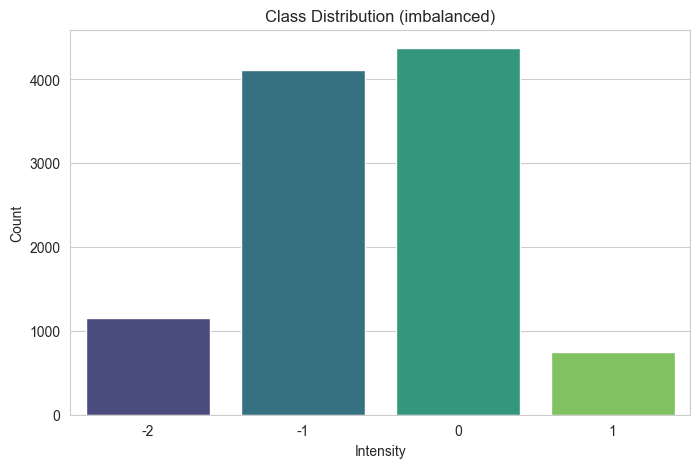

In [5]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.countplot(x="intensity", data=df, order=sorted(df["intensity"].unique()), palette="viridis")
plt.title("Class Distribution (imbalanced)")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()

In [6]:
df["char_length"] = df["posts"].astype(str).apply(len)
df["word_count"] = df["posts"].astype(str).apply(lambda x: len(x.split()))
df[["char_length", "word_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
char_length,10391.0,1178.169281,1583.707073,2.0,452.0,787.0,1344.0,30504.0
word_count,10391.0,234.143393,289.059818,1.0,93.0,162.0,276.0,5413.0


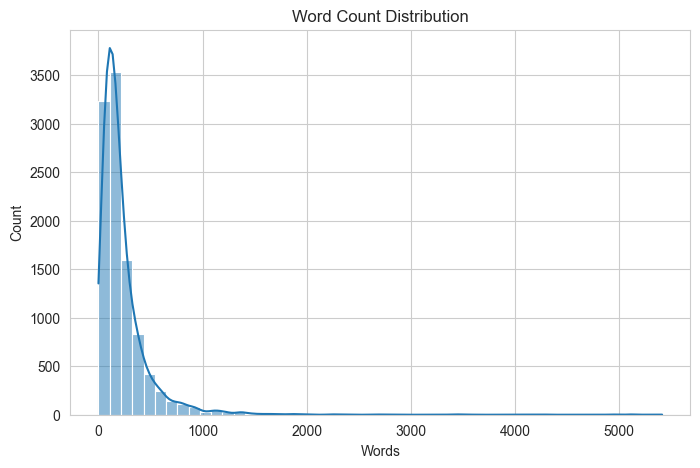

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df["word_count"], bins=50, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.show()

## 4. Preprocessing (one canonical function, used everywhere)

Careful handling of **broken URLs**: in this dataset URLs have already been split into separate space-delimited tokens by whatever process produced the CSV (e.g. `http www allvoice com contribute news 3778829`). A plain `http\S+` regex never matches these because there is no single contiguous token starting with `http`. We first strip any *intact* URLs (`https?://...`, `www....`), then, after tokenizing, drop the specific leftover URL-fragment tokens (`http`, `https`, `www`, `com`, `org`, `net`, `gov`, `edu`, `html`, `htm`, `php`, `co`, `uk`, `jpg`, `png`, `pdf`). Ordinary numbers (years, ages, counts) are always kept, since they matter for sentiment/intensity in this domain. Stopwords are removed except for negation words, which flip meaning and must be preserved.

In [8]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

lemmatizer = WordNetLemmatizer()

NEGATIONS = {
    "not", "no", "nor", "never",
    "don't", "didn't", "doesn't",
    "can't", "won't", "isn't",
    "aren't", "wasn't", "weren't",
    "couldn't", "shouldn't", "wouldn't",
    "haven't", "hasn't", "hadn't",
}
STOPWORDS = set(stopwords.words("english")) - NEGATIONS

# Leftover tokens from URLs that have already been split into separate words
# by upstream processing (broken URLs), plus intact-URL fragments.
URL_FRAGMENT_TOKENS = {
    "http", "https", "www", "com", "org", "net", "gov", "edu",
    "html", "htm", "php", "aspx", "asp", "co", "uk", "jpg", "png",
    "gif", "pdf", "id"
}

URL_REGEX = re.compile(r'(https?://\S+|www\.\S+)')
HTML_TAG_REGEX = re.compile(r'<.*?>')
NON_WORD_REGEX = re.compile(r"[^\w\s']")   # keeps letters, digits, underscore, apostrophes
MULTI_SPACE_REGEX = re.compile(r"\s+")


def clean_text(text):
    """Canonical cleaning + tokenization pipeline.
    MUST be used identically for training data, the held-out test split,
    the external test_data.xlsx, and any brand-new text at inference time.
    Returns a list of lemmatized tokens (verb POS)."""
    text = str(text).lower()
    text = URL_REGEX.sub(" ", text)          # intact URLs (http://..., www....)
    text = HTML_TAG_REGEX.sub(" ", text)     # stray HTML tags
    text = NON_WORD_REGEX.sub(" ", text)     # punctuation -- numbers are kept (\w includes digits)
    text = MULTI_SPACE_REGEX.sub(" ", text).strip()

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in URL_FRAGMENT_TOKENS]   # broken-url remnants
    tokens = [t for t in tokens if t not in STOPWORDS]             # stopwords (negations kept)
    tokens = [lemmatizer.lemmatize(t, pos="v") for t in tokens]    # lemmatize
    return tokens


df["tokens"] = df["posts"].apply(clean_text)
df[["posts", "tokens"]].head()

,posts,tokens
0,I know as parent of child with down syndrome t...,"[know, parent, child, syndrome, hear, child, h..."
1,but in my heart I know this is the future prom...,"[heart, know, future, promise, article, regard..."
2,I have mylefibrosis which turn to leukemia the...,"[mylefibrosis, turn, leukemia, want, stem, cel..."
3,from one of my health group subject wayne dyer...,"[one, health, group, subject, wayne, dyer, leu..."
4,gmos now link to leukemia http nsnbc I 2013 07...,"[gmos, link, leukemia, nsnbc, 2013, 07, 17, gm..."


## 5. Train / Test Split

Split **before** fitting the tokenizer or the embedding models, so nothing about the test set leaks into the vocabulary.

In [9]:
from sklearn.model_selection import train_test_split

X = df["tokens"]
y = df["intensity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(X_train.shape, X_test.shape)

(8312,) (2079,)


## 6. Tokenizer, Padding, Label Encoding

`MAXLEN` is the single global constant defined in the config cell — used here for training and later for every single prediction. Padding/truncating mode is left at Keras defaults (`pre`), which is what the model will implicitly assume at inference too.

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)   # fit ONLY on training tokens - no leakage

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAXLEN)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAXLEN)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)
vocab_size = len(tokenizer.word_index) + 1
print("Vocab size:", vocab_size, "| classes:", le.classes_, "| MAXLEN:", MAXLEN)

Vocab size: 32270 | classes: [-2 -1  0  1] | MAXLEN: 100


## 7. Handling Class Imbalance

The dataset is imbalanced (class `1` has far fewer posts than `0`/`-1`). We oversample **only the training split**, using `RandomOverSampler` on the padded integer sequences (safe for text — unlike `SMOTE`, it duplicates real rows instead of interpolating between token IDs, which would create nonsense sequences). The held-out test split and the external validation file are **never** resampled, so evaluation reflects the true, imbalanced, real-world distribution.

In [11]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = ros.fit_resample(X_train_pad, y_train_enc)

print("Before:", pd.Series(y_train_enc).value_counts().to_dict())
print("After :", pd.Series(y_train_bal).value_counts().to_dict())

Before: {2: 3499, 1: 3289, 0: 924, 3: 600}
After : {1: 3499, 2: 3499, 3: 3499, 0: 3499}


## 8. Embeddings

We train Skip-gram Word2Vec, CBOW Word2Vec, FastText on the **training tokens only** (not the full dataset, to avoid test-set leakage into the embedding space), and load pretrained GloVe vectors. Each embedding gets its **own** embedding matrix — a previous version of this notebook accidentally reused the Skip-gram matrix for the Word2Vec-BiLSTM and FastText-BiLSTM models; that bug is fixed by building a matrix per embedding and never sharing variable names.

In [12]:
get_ipython().run_line_magic("pip", "install -q gensim") if "get_ipython" in globals() else None

Note: you may need to restart the kernel to use updated packages.


In [13]:
from gensim.models import Word2Vec, FastText

train_sentences = X_train.tolist()   # train-only, avoids leaking test vocabulary into embeddings

skipgram_model = Word2Vec(sentences=train_sentences, vector_size=EMBED_DIM, window=5,
                           min_count=2, workers=4, sg=1, seed=RANDOM_STATE)

cbow_model = Word2Vec(sentences=train_sentences, vector_size=EMBED_DIM, window=5,
                       min_count=2, workers=4, sg=0, seed=RANDOM_STATE)

fasttext_model = FastText(sentences=train_sentences, vector_size=EMBED_DIM, window=5,
                           min_count=2, workers=4, seed=RANDOM_STATE)

def build_embedding_matrix(w2v_like_model, tokenizer, vocab_size, embed_dim):
    matrix = np.zeros((vocab_size, embed_dim))
    hits = 0
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        if word in w2v_like_model.wv:
            matrix[idx] = w2v_like_model.wv[word]
            hits += 1
    print(f"  matched {hits}/{len(tokenizer.word_index)} vocab words")
    return matrix

print("Skip-gram embedding matrix:")
embedding_matrix_skipgram = build_embedding_matrix(skipgram_model, tokenizer, vocab_size, EMBED_DIM)
print("CBOW / Word2Vec embedding matrix:")
embedding_matrix_w2v = build_embedding_matrix(cbow_model, tokenizer, vocab_size, EMBED_DIM)
print("FastText embedding matrix:")
embedding_matrix_ft = build_embedding_matrix(fasttext_model, tokenizer, vocab_size, EMBED_DIM)

Skip-gram embedding matrix:
  matched 17096/32269 vocab words
CBOW / Word2Vec embedding matrix:
  matched 17096/32269 vocab words
FastText embedding matrix:
  matched 32269/32269 vocab words


In [14]:
# GloVe - pretrained vectors. Update the path to your local glove.6B.100d.txt
GLOVE_PATH = r"F:\TechJobs-Tasks\NLP\NLP-PROJECT\glove.6B\glove.6B.100d.txt"

embeddings_index = {}
if os.path.exists(GLOVE_PATH):
    with open(GLOVE_PATH, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype="float32")
            embeddings_index[word] = vector
    print("Loaded", len(embeddings_index), "GloVe vectors.")
else:
    print(f"GloVe file not found at '{GLOVE_PATH}'. Skipping GloVe models "
          f"(download glove.6B.zip from https://nlp.stanford.edu/data/glove.6B.zip and update GLOVE_PATH).")

embedding_matrix_glove = np.zeros((vocab_size, EMBED_DIM))
if embeddings_index:
    hits = 0
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix_glove[idx] = vec
            hits += 1
    print(f"  matched {hits}/{len(tokenizer.word_index)} vocab words")

Loaded 400000 GloVe vectors.
  matched 21510/32269 vocab words


## 9. Model Training Helper

A single builder/trainer used by every architecture so all 12 models are trained **identically** — same padding, same callbacks, same class balancing, same evaluation. `EarlyStopping` (on `val_loss`, restoring the best epoch's weights) plus `ReduceLROnPlateau` replace the old fixed `epochs=30` with no safeguard, so each model trains for exactly as many epochs as it needs, no more, no less.

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

trained_models = {}
histories = {}
eval_rows = []


def build_model(embedding_matrix, rnn_type, trainable_embeddings=False):
    model = Sequential()
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAXLEN,
        trainable=trainable_embeddings,
    ))
    if rnn_type == "LSTM":
        model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
    elif rnn_type == "GRU":
        model.add(GRU(128, dropout=0.2, recurrent_dropout=0.2))
    elif rnn_type == "BiLSTM":
        model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))
    else:
        raise ValueError(rnn_type)
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation="softmax"))
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def train_and_evaluate(name, embedding_matrix, rnn_type):
    print("=" * 70)
    print(name)
    print("=" * 70)
    model = build_model(embedding_matrix, rnn_type)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ]

    history = model.fit(
        X_train_bal, y_train_bal,
        validation_data=(X_test_pad, y_test_enc),   # untouched, non-oversampled hold-out
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )

    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    print(classification_report(y_test_enc, y_pred, target_names=[str(c) for c in le.classes_]))
    cm = confusion_matrix(y_test_enc, y_pred)
    print(cm)

    y_test_bin = label_binarize(y_test_enc, classes=np.arange(num_classes))
    try:
        roc_auc = roc_auc_score(y_test_bin, y_pred_prob, multi_class="ovr", average="macro")
    except ValueError:
        roc_auc = np.nan

    from sklearn.metrics import accuracy_score, f1_score
    eval_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_enc, y_pred),
        "F1 (macro)": f1_score(y_test_enc, y_pred, average="macro"),
        "F1 (weighted)": f1_score(y_test_enc, y_pred, average="weighted"),
        "ROC-AUC (macro OvR)": roc_auc,
        "Epochs trained": len(history.history["loss"]),
    })

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title(f"{name} — Accuracy"); plt.xlabel("Epoch"); plt.legend(); plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"{name} — Loss"); plt.xlabel("Epoch"); plt.legend(); plt.show()

    trained_models[name] = model
    histories[name] = history
    return model, history

## 10. Train All 12 Models (Skip-gram / Word2Vec / FastText / GloVe × LSTM / GRU / BiLSTM)

Skip-Gram + LSTM
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 104s 213ms/step - accuracy: 0.5305 - loss: 1.0842 - val_accuracy: 0.6104 - val_loss: 0.8716 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 151s 234ms/step - accuracy: 0.6160 - loss: 0.9454 - val_accuracy: 0.6056 - val_loss: 0.8927 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 101s 230ms/step - accuracy: 0.6450 - loss: 0.8910 - val_accuracy: 0.6258 - val_loss: 0.8234 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 97s 221ms/step - accuracy: 0.6615 - loss: 0.8527 - val_accuracy: 0.6763 - val_loss: 0.7723 - learning_rate: 0.0010
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 95s 217ms/step - accuracy: 0.6750 - loss: 0.8072 - val_accuracy: 0.6662 - val_loss: 0.7996 - learning_rate: 0.0010
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 96s 218ms/step - accuracy: 0.7011 - loss: 0.7635 - val_accuracy: 0.6397 - val_loss: 0.8042 - learning_rate: 0.0010
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 144s 224ms

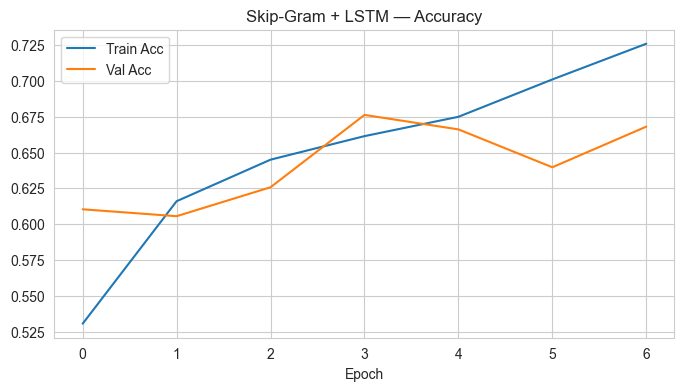

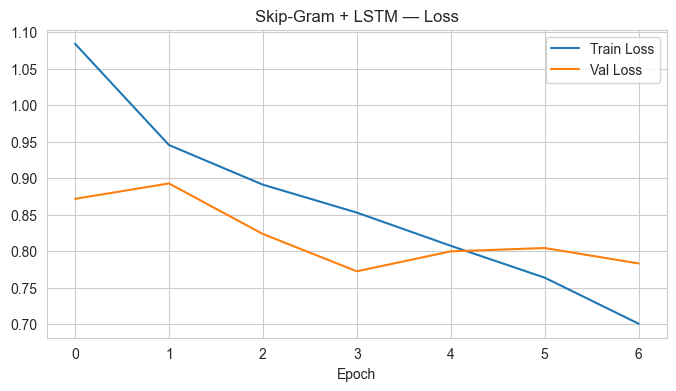

Skip-Gram + GRU
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 99s 200ms/step - accuracy: 0.5297 - loss: 1.0871 - val_accuracy: 0.6171 - val_loss: 0.9123 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 80s 182ms/step - accuracy: 0.6319 - loss: 0.9153 - val_accuracy: 0.6474 - val_loss: 0.8325 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.6597 - loss: 0.8498 - val_accuracy: 0.6392 - val_loss: 0.8303 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 72s 164ms/step - accuracy: 0.6883 - loss: 0.7893 - val_accuracy: 0.6344 - val_loss: 0.8334 - learning_rate: 0.0010
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 52s 119ms/step - accuracy: 0.7065 - loss: 0.7473 - val_accuracy: 0.6518 - val_loss: 0.7953 - learning_rate: 0.0010
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 50s 115ms/step - accuracy: 0.7281 - loss: 0.6986 - val_accuracy: 0.6729 - val_loss: 0.7534 - learning_rate: 0.0010
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 71s 163ms/step

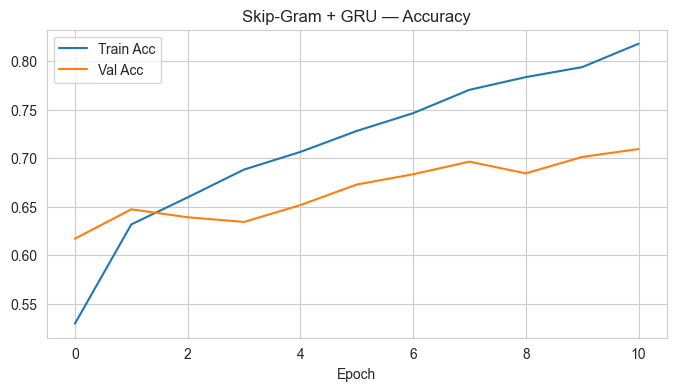

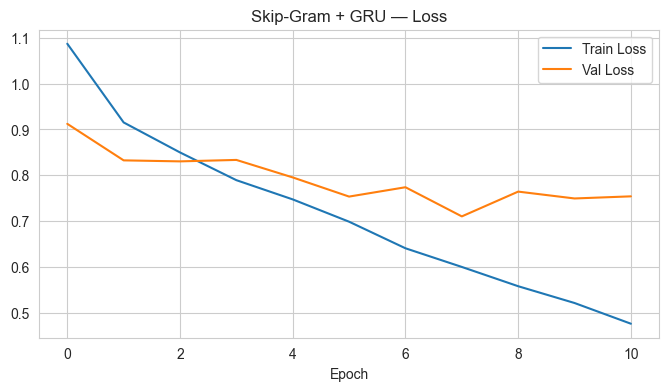

Skip-Gram + BiLSTM
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 229s 483ms/step - accuracy: 0.5517 - loss: 1.0492 - val_accuracy: 0.6320 - val_loss: 0.8403 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 193s 440ms/step - accuracy: 0.6291 - loss: 0.9186 - val_accuracy: 0.6272 - val_loss: 0.8672 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 184s 419ms/step - accuracy: 0.6516 - loss: 0.8645 - val_accuracy: 0.6330 - val_loss: 0.8475 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 182s 415ms/step - accuracy: 0.6821 - loss: 0.7922 - val_accuracy: 0.6638 - val_loss: 0.7941 - learning_rate: 5.0000e-04
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 181s 412ms/step - accuracy: 0.6909 - loss: 0.7647 - val_accuracy: 0.6166 - val_loss: 0.8687 - learning_rate: 5.0000e-04
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 169s 386ms/step - accuracy: 0.7127 - loss: 0.7291 - val_accuracy: 0.6489 - val_loss: 0.7987 - learning_rate: 5.0000e-04
Epoch 7/25
438/438 ━━━━━━━━━━━━━━

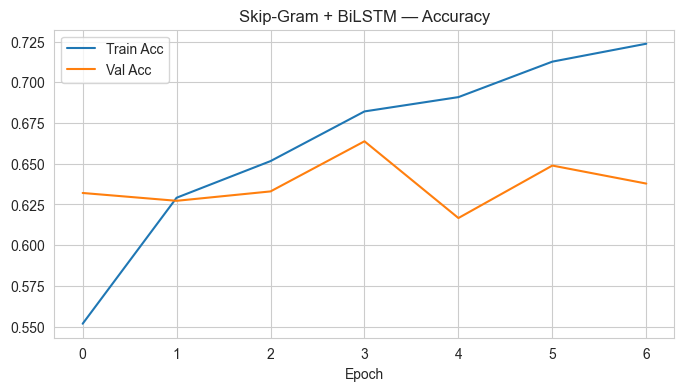

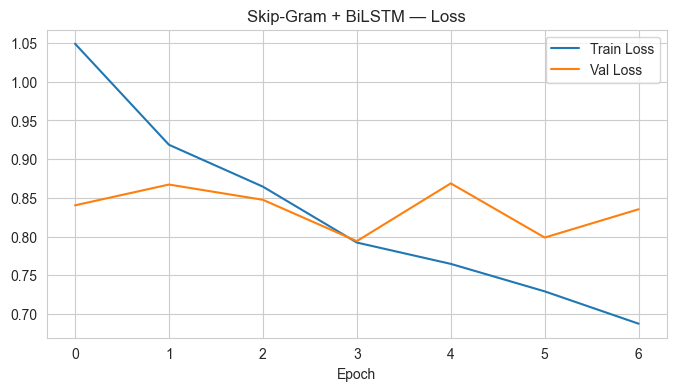

In [16]:
for rnn_type in ["LSTM", "GRU", "BiLSTM"]:
    train_and_evaluate(f"Skip-Gram + {rnn_type}", embedding_matrix_skipgram, rnn_type)

Word2Vec + LSTM
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.5757 - loss: 1.0206 - val_accuracy: 0.5580 - val_loss: 0.9739 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 62s 142ms/step - accuracy: 0.6478 - loss: 0.8866 - val_accuracy: 0.6138 - val_loss: 0.8769 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 188ms/step - accuracy: 0.6776 - loss: 0.8094 - val_accuracy: 0.5998 - val_loss: 0.9228 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 140s 183ms/step - accuracy: 0.7036 - loss: 0.7482 - val_accuracy: 0.6426 - val_loss: 0.8425 - learning_rate: 0.0010
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 81s 184ms/step - accuracy: 0.7334 - loss: 0.6799 - val_accuracy: 0.6643 - val_loss: 0.8393 - learning_rate: 0.0010
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 76s 174ms/step - accuracy: 0.7580 - loss: 0.6191 - val_accuracy: 0.6580 - val_loss: 0.8853 - learning_rate: 0.0010
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 174ms/ste

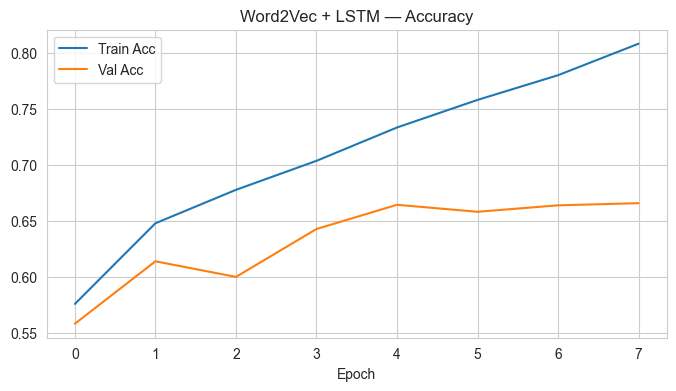

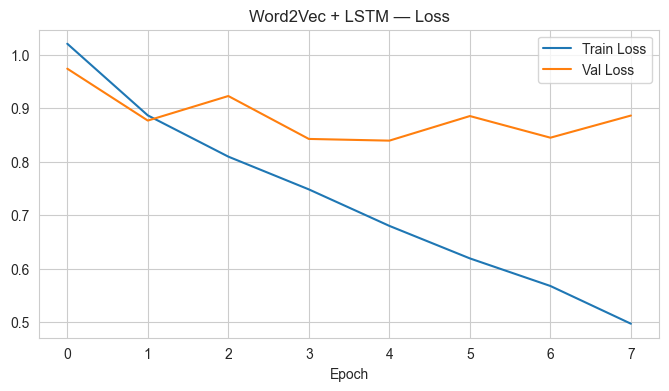

Word2Vec + GRU
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 76s 154ms/step - accuracy: 0.5447 - loss: 1.0614 - val_accuracy: 0.6585 - val_loss: 0.7979 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 63s 144ms/step - accuracy: 0.6487 - loss: 0.8798 - val_accuracy: 0.6306 - val_loss: 0.8278 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 57s 131ms/step - accuracy: 0.6816 - loss: 0.8017 - val_accuracy: 0.6089 - val_loss: 0.8919 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 66s 151ms/step - accuracy: 0.7140 - loss: 0.7240 - val_accuracy: 0.6734 - val_loss: 0.7478 - learning_rate: 5.0000e-04
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 65s 147ms/step - accuracy: 0.7301 - loss: 0.6905 - val_accuracy: 0.6441 - val_loss: 0.8412 - learning_rate: 5.0000e-04
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 62s 141ms/step - accuracy: 0.7469 - loss: 0.6541 - val_accuracy: 0.6522 - val_loss: 0.8150 - learning_rate: 5.0000e-04
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 64s

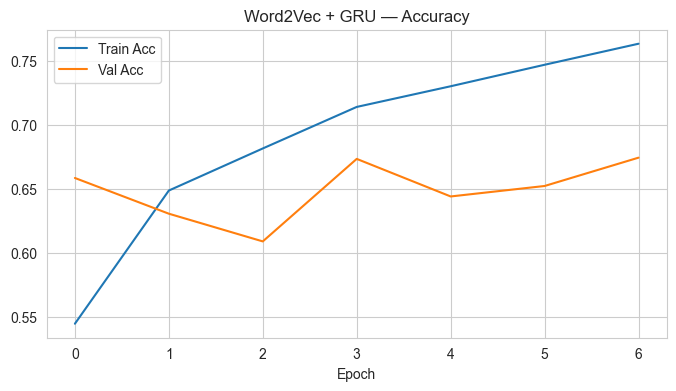

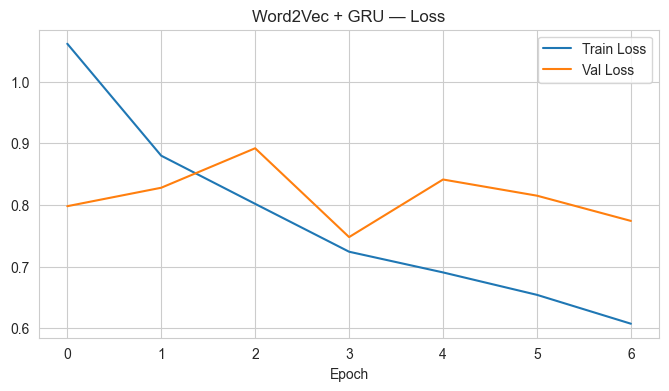

Word2Vec + BiLSTM
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 232s 487ms/step - accuracy: 0.5846 - loss: 1.0016 - val_accuracy: 0.6272 - val_loss: 0.8711 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 220s 502ms/step - accuracy: 0.6649 - loss: 0.8422 - val_accuracy: 0.6561 - val_loss: 0.8133 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 205s 467ms/step - accuracy: 0.7026 - loss: 0.7555 - val_accuracy: 0.6715 - val_loss: 0.7917 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 185s 421ms/step - accuracy: 0.7331 - loss: 0.6812 - val_accuracy: 0.6474 - val_loss: 0.8660 - learning_rate: 0.0010
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 189s 432ms/step - accuracy: 0.7704 - loss: 0.5979 - val_accuracy: 0.6748 - val_loss: 0.7959 - learning_rate: 0.0010
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 187s 428ms/step - accuracy: 0.8094 - loss: 0.4986 - val_accuracy: 0.6772 - val_loss: 0.8377 - learning_rate: 5.0000e-04
              precision    recall  f1-scor

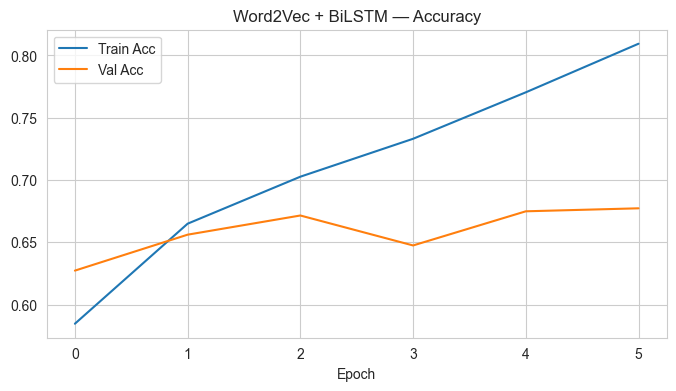

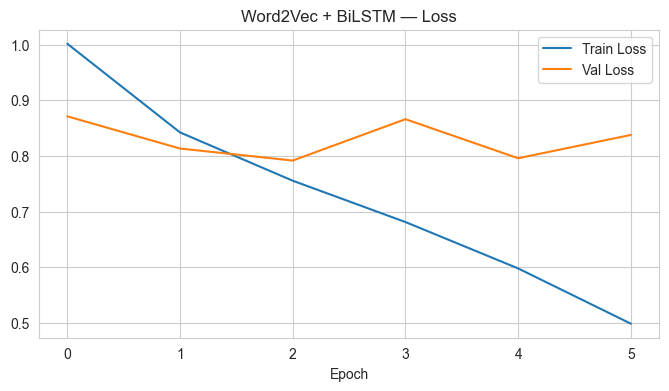

In [17]:
for rnn_type in ["LSTM", "GRU", "BiLSTM"]:
    train_and_evaluate(f"Word2Vec + {rnn_type}", embedding_matrix_w2v, rnn_type)

FastText + LSTM
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 90s 190ms/step - accuracy: 0.5615 - loss: 1.0381 - val_accuracy: 0.5599 - val_loss: 0.9485 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 186ms/step - accuracy: 0.6460 - loss: 0.8783 - val_accuracy: 0.6383 - val_loss: 0.8440 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 188ms/step - accuracy: 0.6734 - loss: 0.8164 - val_accuracy: 0.6417 - val_loss: 0.8386 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 186ms/step - accuracy: 0.7038 - loss: 0.7483 - val_accuracy: 0.6368 - val_loss: 0.8716 - learning_rate: 0.0010
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 188ms/step - accuracy: 0.7331 - loss: 0.6793 - val_accuracy: 0.6503 - val_loss: 0.8412 - learning_rate: 0.0010
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 73s 165ms/step - accuracy: 0.7634 - loss: 0.5950 - val_accuracy: 0.6633 - val_loss: 0.8324 - learning_rate: 5.0000e-04
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 68s 155ms/

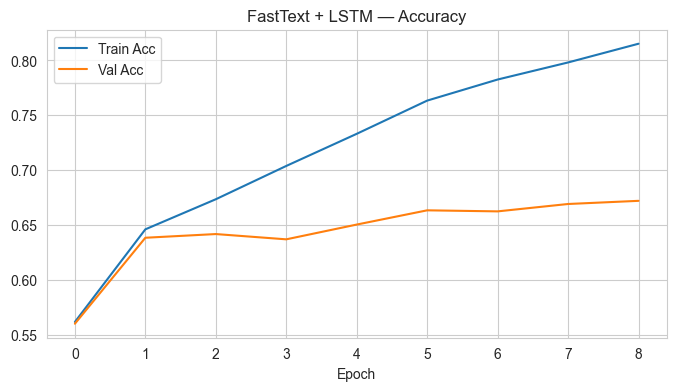

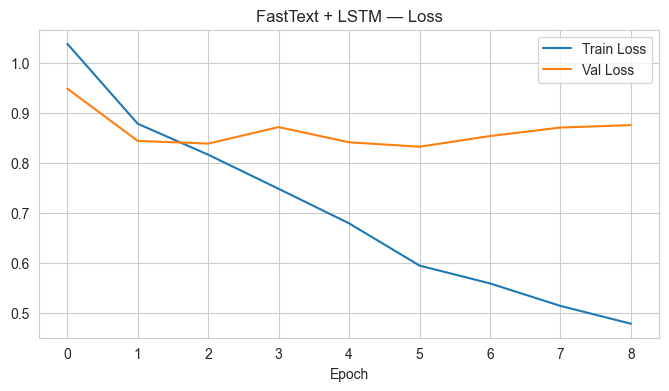

FastText + GRU
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 34s 70ms/step - accuracy: 0.5286 - loss: 1.0888 - val_accuracy: 0.5589 - val_loss: 0.9461 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.6321 - loss: 0.8978 - val_accuracy: 0.6181 - val_loss: 0.8734 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.6763 - loss: 0.8094 - val_accuracy: 0.6518 - val_loss: 0.7797 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.7036 - loss: 0.7490 - val_accuracy: 0.6580 - val_loss: 0.7835 - learning_rate: 0.0010
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.7329 - loss: 0.6805 - val_accuracy: 0.6734 - val_loss: 0.7783 - learning_rate: 0.0010
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.7619 - loss: 0.6138 - val_accuracy: 0.6821 - val_loss: 0.7916 - learning_rate: 0.0010
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - accur

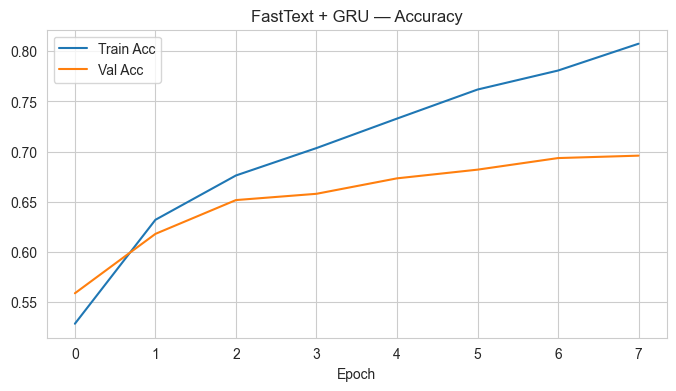

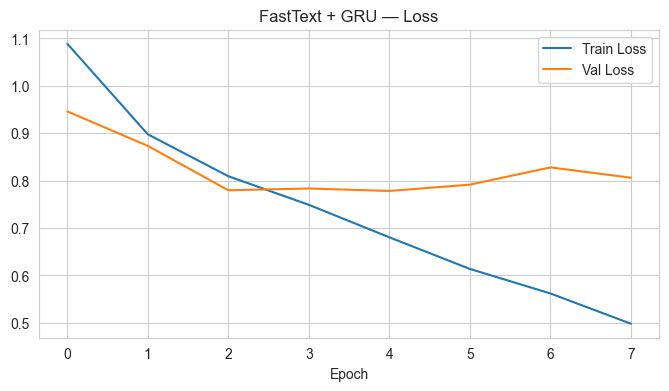

FastText + BiLSTM
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 116s 253ms/step - accuracy: 0.5712 - loss: 1.0113 - val_accuracy: 0.5988 - val_loss: 0.9254 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 111s 254ms/step - accuracy: 0.6500 - loss: 0.8564 - val_accuracy: 0.6190 - val_loss: 0.8705 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 121s 275ms/step - accuracy: 0.7004 - loss: 0.7590 - val_accuracy: 0.6392 - val_loss: 0.8473 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 161s 367ms/step - accuracy: 0.7374 - loss: 0.6704 - val_accuracy: 0.6633 - val_loss: 0.8507 - learning_rate: 0.0010
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 134s 306ms/step - accuracy: 0.7734 - loss: 0.5848 - val_accuracy: 0.6585 - val_loss: 0.8807 - learning_rate: 0.0010
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 138s 315ms/step - accuracy: 0.8171 - loss: 0.4773 - val_accuracy: 0.6705 - val_loss: 0.8616 - learning_rate: 5.0000e-04
              precision    recall  f1-scor

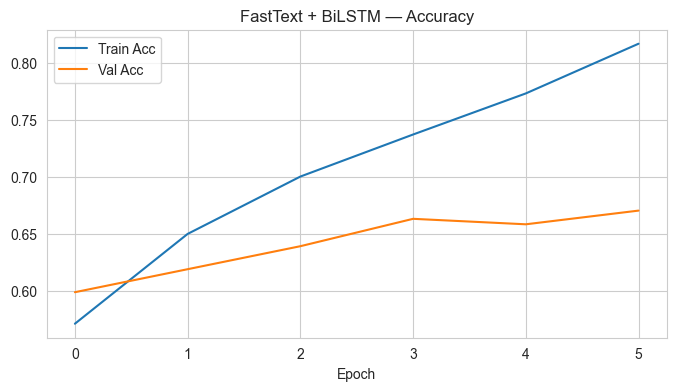

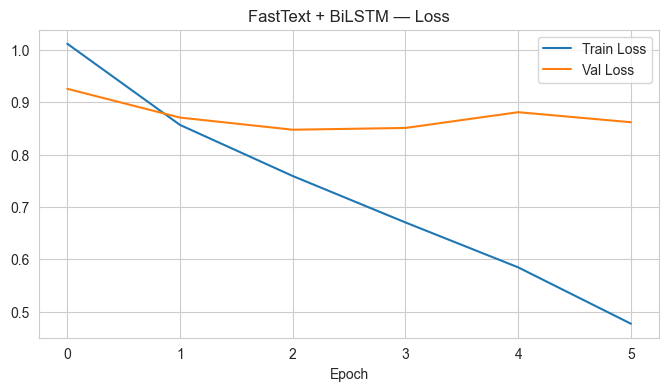

In [18]:
for rnn_type in ["LSTM", "GRU", "BiLSTM"]:
    train_and_evaluate(f"FastText + {rnn_type}", embedding_matrix_ft, rnn_type)

GloVe + LSTM
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 63s 132ms/step - accuracy: 0.5338 - loss: 1.0842 - val_accuracy: 0.6022 - val_loss: 0.9152 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 57s 131ms/step - accuracy: 0.6257 - loss: 0.9314 - val_accuracy: 0.5940 - val_loss: 0.9141 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 55s 126ms/step - accuracy: 0.6705 - loss: 0.8378 - val_accuracy: 0.6301 - val_loss: 0.8767 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 56s 127ms/step - accuracy: 0.7023 - loss: 0.7547 - val_accuracy: 0.6460 - val_loss: 0.8065 - learning_rate: 0.0010
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 60s 137ms/step - accuracy: 0.7378 - loss: 0.6736 - val_accuracy: 0.6811 - val_loss: 0.7583 - learning_rate: 0.0010
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 58s 133ms/step - accuracy: 0.7644 - loss: 0.5983 - val_accuracy: 0.6647 - val_loss: 0.8194 - learning_rate: 0.0010
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 72s 110ms/step - 

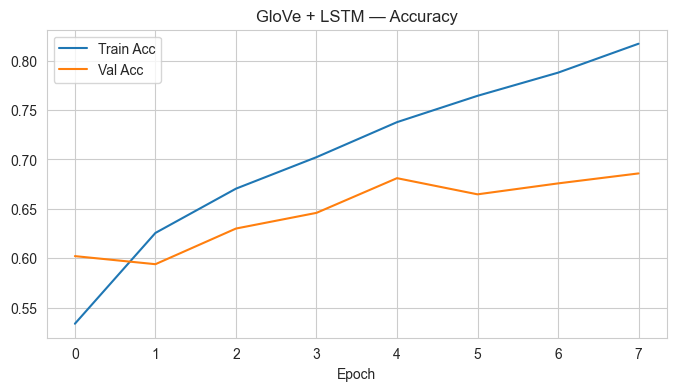

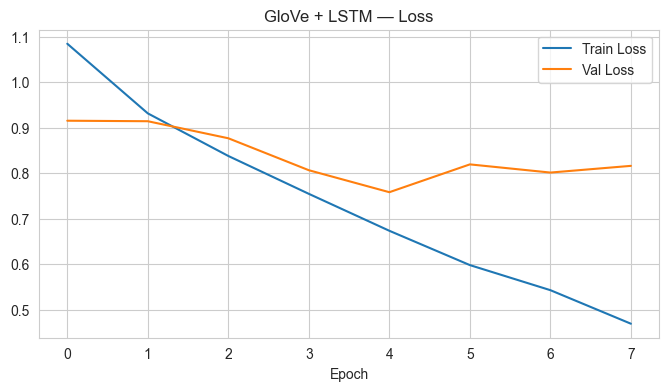

GloVe + GRU
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 55s 119ms/step - accuracy: 0.5086 - loss: 1.1175 - val_accuracy: 0.6263 - val_loss: 0.8815 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 52s 118ms/step - accuracy: 0.6386 - loss: 0.9022 - val_accuracy: 0.6787 - val_loss: 0.7723 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 52s 118ms/step - accuracy: 0.6872 - loss: 0.7996 - val_accuracy: 0.6325 - val_loss: 0.8471 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 69s 87ms/step - accuracy: 0.7280 - loss: 0.7071 - val_accuracy: 0.6671 - val_loss: 0.7661 - learning_rate: 0.0010
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 49s 111ms/step - accuracy: 0.7513 - loss: 0.6383 - val_accuracy: 0.6623 - val_loss: 0.8063 - learning_rate: 0.0010
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 53s 122ms/step - accuracy: 0.7794 - loss: 0.5750 - val_accuracy: 0.6797 - val_loss: 0.7891 - learning_rate: 0.0010
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 47s 107ms/step - ac

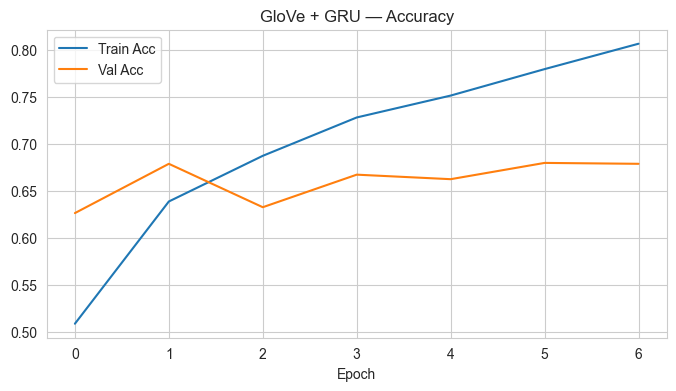

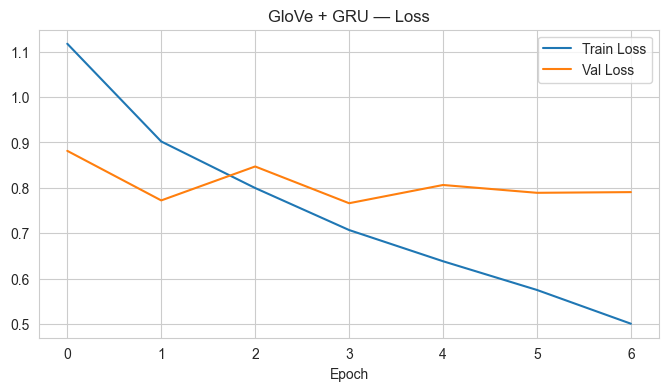

GloVe + BiLSTM
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 127s 277ms/step - accuracy: 0.5259 - loss: 1.0813 - val_accuracy: 0.6152 - val_loss: 0.8922 - learning_rate: 0.0010
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 115s 263ms/step - accuracy: 0.6420 - loss: 0.8873 - val_accuracy: 0.6445 - val_loss: 0.8326 - learning_rate: 0.0010
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 120s 273ms/step - accuracy: 0.6902 - loss: 0.7824 - val_accuracy: 0.6445 - val_loss: 0.8443 - learning_rate: 0.0010
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 141s 270ms/step - accuracy: 0.7315 - loss: 0.6807 - val_accuracy: 0.6614 - val_loss: 0.8131 - learning_rate: 0.0010
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 140s 265ms/step - accuracy: 0.7716 - loss: 0.5902 - val_accuracy: 0.6465 - val_loss: 0.8653 - learning_rate: 0.0010
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 115s 263ms/step - accuracy: 0.7977 - loss: 0.5239 - val_accuracy: 0.6518 - val_loss: 0.8635 - learning_rate: 0.0010
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 169s 325m

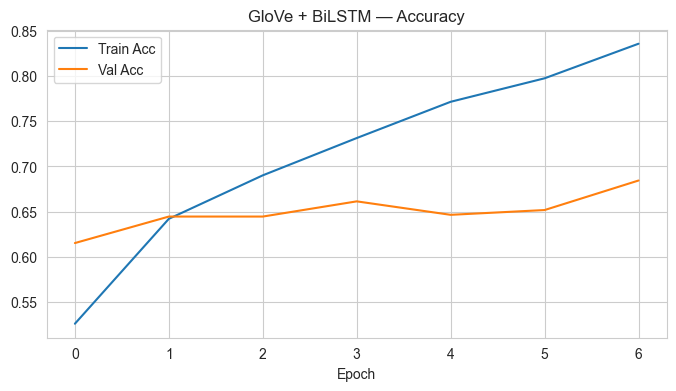

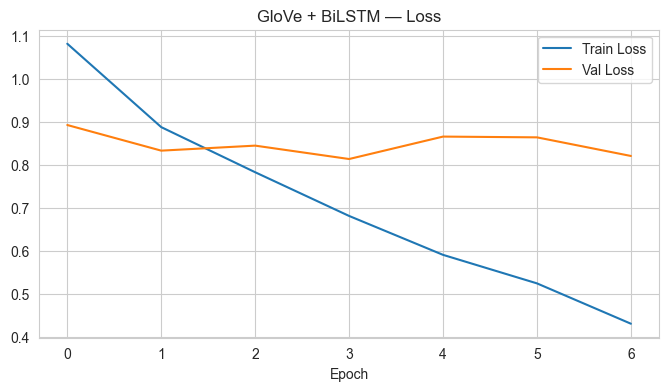

In [19]:
if embeddings_index:
    for rnn_type in ["LSTM", "GRU", "BiLSTM"]:
        train_and_evaluate(f"GloVe + {rnn_type}", embedding_matrix_glove, rnn_type)
else:
    print("Skipping GloVe models - glove.6B.100d.txt not found (see GLOVE_PATH above).")

## 11. Compare All Models

In [20]:
results_df = pd.DataFrame(eval_rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,F1 (macro),F1 (weighted),ROC-AUC (macro OvR),Epochs trained
0,Skip-Gram + GRU,0.696489,0.639568,0.704475,0.893541,11
1,Word2Vec + BiLSTM,0.671477,0.629026,0.680257,0.867156,6
2,FastText + GRU,0.673401,0.628163,0.682210,0.877625,8
3,Word2Vec + GRU,0.673401,0.627257,0.679407,0.882665,7
4,GloVe + LSTM,0.681097,0.625635,0.684128,0.876097,8
5,Skip-Gram + BiLSTM,0.663781,0.623509,0.666722,0.882277,7
6,GloVe + GRU,0.667148,0.621958,0.673306,0.878385,7
7,Word2Vec + LSTM,0.664262,0.621725,0.674789,0.866791,8
8,Skip-Gram + LSTM,0.676287,0.620376,0.682453,0.877620,7
9,GloVe + BiLSTM,0.661376,0.614965,0.668060,0.867833,7


In [21]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print("Best model on the held-out (imbalanced, real-world) test split:", best_model_name)

Best model on the held-out (imbalanced, real-world) test split: Skip-Gram + GRU


## 12. Save Everything Needed For Inference

**This is the fix for the original bug.** Predicting on new data in a different session requires the *exact* fitted `tokenizer` and `LabelEncoder` used during training, plus the `MAXLEN` used for padding — not a freshly re-fit tokenizer. All of these are now saved to disk together with the model, instead of the pickle cells being left commented out.

In [22]:
for name, model in trained_models.items():
    fname = os.path.join(ARTIFACT_DIR, name.lower().replace(" ", "_").replace("+", "") + ".keras")
    model.save(fname)

with open(os.path.join(ARTIFACT_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)

with open(os.path.join(ARTIFACT_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)

with open(os.path.join(ARTIFACT_DIR, "config.json"), "w") as f:
    json.dump({"MAXLEN": MAXLEN, "best_model": best_model_name}, f)

print("Saved model(s), tokenizer, label encoder and config to:", ARTIFACT_DIR)

Saved model(s), tokenizer, label encoder and config to: artifacts


## 13. Consistent Inference on New / Unseen Data

`predict_texts` re-uses the **exact same** `clean_text`, `tokenizer`, `MAXLEN` and `LabelEncoder` as training. This is the function to call for any new data — never re-fit a tokenizer or hand-roll a different cleaning step for prediction.

In [23]:
def predict_texts(model, raw_texts, tokenizer=tokenizer, label_encoder=le, maxlen=MAXLEN):
    """raw_texts: list/Series of raw, un-preprocessed strings."""
    tokens = [clean_text(t) for t in raw_texts]
    seqs = tokenizer.texts_to_sequences(tokens)
    padded = pad_sequences(seqs, maxlen=maxlen)
    probs = model.predict(padded, verbose=0)
    pred_idx = np.argmax(probs, axis=1)
    return label_encoder.inverse_transform(pred_idx), probs


sample_text = ("its been 2 years and like many, it was the first very personal relationship I had "
               "with a girl. To this day I always say that she passed away from cancer (leukemia), "
               "to be exact, yes she had leukemia.")
pred_label, probs = predict_texts(best_model, [sample_text])
print("Predicted intensity:", pred_label[0])

Predicted intensity: 0


In [24]:
# ---- Evaluate on the externally provided test_data.xlsx (unseen data, true labels included) ----
try:
    import openpyxl  # noqa: F401
except ImportError:
    get_ipython().run_line_magic("pip", "install -q openpyxl") if "get_ipython" in globals() else None

external_df = pd.read_excel(EXTERNAL_TEST_PATH)
external_df = external_df.dropna(subset=["posts"]).reset_index(drop=True)

pred_labels, pred_probs = predict_texts(best_model, external_df["posts"])
external_df["Predicted"] = pred_labels

if "intensity" in external_df.columns:
    from sklearn.metrics import accuracy_score, classification_report
    acc = accuracy_score(external_df["intensity"], external_df["Predicted"])
    print(f"External test-set accuracy ({best_model_name}): {acc:.3f}")
    print(classification_report(external_df["intensity"], external_df["Predicted"]))

external_df[["posts", "intensity", "Predicted"]] if "intensity" in external_df.columns else external_df[["posts", "Predicted"]]

External test-set accuracy (Skip-Gram + GRU): 0.900
              precision    recall  f1-score   support

          -2       0.83      1.00      0.91        10
          -1       0.88      0.70      0.78        10
           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



,posts,intensity,Predicted
0,I know as parent of child with down syndrome t...,-1,-1
1,tomorrow sept 9 will be one year since I leave...,-1,-2
2,I start with severe headache in jan and was fo...,-1,-1
3,ok so I was look up to see why my gum were ble...,-1,-1
4,hi I m 15 and was just diagnose with leukemia ...,-1,-1
5,mandy is only 24 she is such a sweet friend he...,-1,1
6,I am a new member and hope to find some suppor...,-1,-2
7,so my new illne lymphoma start out as flesh ea...,-1,-1
8,my brother was diagnose with leukemia about a ...,-1,-1
9,I have mylefibrosis which turn to leukemia the...,-1,-1


## 14. Loading Saved Artifacts In a Fresh Session (e.g. a separate VS Code script)

This is exactly what a standalone prediction script should do — load the saved tokenizer / label encoder / model, redefine (or import) the same `clean_text` function, and call `predict_texts`. Never re-fit a new `Tokenizer()` on the new data; that produces a different vocabulary→index mapping than the one the model was trained on, which silently produces near-random predictions — this was very likely the root cause of the original misclassification issue.

In [25]:
# Example of a fresh-session inference script (kept here for reference / copy-paste):
#
# import pickle, json, numpy as np
# from tensorflow.keras.models import load_model
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# # ... paste the same `clean_text` function here (or import it from a shared module) ...
#
# with open("artifacts/tokenizer.pkl", "rb") as f:
#     tokenizer = pickle.load(f)
# with open("artifacts/label_encoder.pkl", "rb") as f:
#     le = pickle.load(f)
# with open("artifacts/config.json") as f:
#     cfg = json.load(f)
#
# model = load_model(f"artifacts/{cfg['best_model'].lower().replace(' ', '_').replace('+', '')}.keras")
#
# def predict_texts(model, raw_texts, tokenizer=tokenizer, label_encoder=le, maxlen=cfg["MAXLEN"]):
#     tokens = [clean_text(t) for t in raw_texts]
#     seqs = tokenizer.texts_to_sequences(tokens)
#     padded = pad_sequences(seqs, maxlen=maxlen)
#     probs = model.predict(padded, verbose=0)
#     return label_encoder.inverse_transform(np.argmax(probs, axis=1)), probs
print("See markdown cell above for the fresh-session inference template.")

See markdown cell above for the fresh-session inference template.
